# Initial exploration of GMD_all_2017

This notebook documents the structure, coverage, and granularity of `GMD_all_2017.dta` before applying any top-censoring diagnostics.


The file may combine microdata and grouped distributions. Therefore, this first stage does not calculate an LIS ceiling or identify extreme observations. It first verifies that each country-year has individual data, an interpretable welfare variable, and an appropriate weight.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / '01-input' / 'GMD_all_2017.dta').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Could not find bindata_check/01-input/GMD_all_2017.dta from the current directory.')

DATA_PATH = ROOT / '01-input' / 'GMD_all_2017.dta'
print(f'Path: {DATA_PATH}')
print(f'Size: {DATA_PATH.stat().st_size / 1024**2:.1f} MB')

Ruta: c:\Users\wb661551\OneDrive - WBG\Desktop\Internship\Bottom Censoring\bindata_check\01-input\GMD_all_2017.dta
Tamano: 3599.1 MB


In [ ]:
SAMPLE_ROWS = 10_000
reader = pd.read_stata(DATA_PATH, iterator=True)
gmd = reader.read(nrows=SAMPLE_ROWS)
print(f'Records loaded for exploration: {len(gmd):,}')
print(f'Columns: {len(gmd.columns):,}')
display(gmd.head(10))
print('Column names:')
print(list(gmd.columns))
print('Note: the following tables describe this sample; exact statistics for the full file will use chunked reading.')

Registros cargados para exploracion: 10,000
Columnas: 16


,welfare_dec,weight,x,code,year,survname,mod,survey_coverage,datatype,use_imputed,use_microdata,use_bin,use_groupdata,rep_year,comparability,ref_year
0,3.019204,331.202479,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21
1,0.752875,54.293851,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21
2,6.275093,1400.377218,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21
3,2.697000,2363.863898,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21
4,18.643509,853.056297,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21
5,4.676421,782.255772,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21
6,7.632235,764.853495,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21
7,3.788897,34.496150,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21
8,3.601982,178.858134,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21
9,64.264793,705.996810,1,AGO,2000,HBS,GPWG,N,c,0,1,0,0,2000,0,2000.21


Nombres de columnas:
['welfare_dec', 'weight', 'x', 'code', 'year', 'survname', 'mod', 'survey_coverage', 'datatype', 'use_imputed', 'use_microdata', 'use_bin', 'use_groupdata', 'rep_year', 'comparability', 'ref_year']
Nota: las tablas siguientes describen esta muestra; para estadisticas exactas sobre todo el archivo usaremos lectura por chunks.


## Full exploration using chunks

The complete file is too large to load as a single `DataFrame`. The following cell scans it in blocks of 25,000 rows and retains only accumulators and small summary tables. These results use all rows.

In [ ]:
CHUNK_ROWS = 25_000
id_columns = ['code', 'year', 'survname', 'datatype', 'use_microdata', 'use_bin', 'use_groupdata']
numeric_columns = ['welfare_dec', 'weight', 'x', 'year', 'use_imputed', 'use_microdata', 'use_bin', 'use_groupdata', 'rep_year', 'comparability', 'ref_year']
columns_to_read = sorted(set(id_columns + numeric_columns))

total_rows = 0
missing_counts = None
numeric_totals = {column: {'sum': 0.0, 'non_missing': 0, 'minimum': np.inf, 'maximum': -np.inf, 'negative': 0} for column in numeric_columns}
coverage_parts = []

reader = pd.read_stata(DATA_PATH, iterator=True, chunksize=CHUNK_ROWS, columns=columns_to_read)
for chunk_number, chunk in enumerate(reader, start=1):
    total_rows += len(chunk)
    if missing_counts is None:
        missing_counts = chunk.isna().sum().astype('int64')
    else:
        missing_counts = missing_counts.add(chunk.isna().sum(), fill_value=0).astype('int64')

    available_ids = [column for column in id_columns if column in chunk.columns]
    coverage_parts.append(chunk.groupby(available_ids, dropna=False, observed=True).size().rename('records').reset_index())

    for column in numeric_columns:
        if column not in chunk.columns:
            continue
        values = pd.to_numeric(chunk[column], errors='coerce')
        finite = values[np.isfinite(values)]
        numeric_totals[column]['sum'] += float(finite.sum())
        numeric_totals[column]['non_missing'] += int(finite.size)
        if finite.size:
            numeric_totals[column]['minimum'] = min(numeric_totals[column]['minimum'], float(finite.min()))
            numeric_totals[column]['maximum'] = max(numeric_totals[column]['maximum'], float(finite.max()))
            numeric_totals[column]['negative'] += int((finite < 0).sum())

coverage_full = pd.concat(coverage_parts, ignore_index=True).groupby(id_columns, dropna=False, observed=True)['records'].sum().reset_index()
missing_full = pd.DataFrame({'missing': missing_counts, 'missing_pct': 100 * missing_counts / total_rows})
numeric_full = pd.DataFrame(numeric_totals).T.rename_axis('variable').reset_index()
numeric_full['missing'] = total_rows - numeric_full['non_missing']
numeric_full['mean'] = numeric_full['sum'] / numeric_full['non_missing']
numeric_full = numeric_full[['variable', 'non_missing', 'missing', 'mean', 'minimum', 'maximum', 'negative']]

print(f'Rows processed in the full file: {total_rows:,}')
print(f'Blocks processed: {chunk_number:,}')
display(missing_full)
display(numeric_full)
display(coverage_full.sort_values('records', ascending=False).head(30))

MemoryError: 

## Variable dictionary

The following table is calculated from the loaded sample and provides a quick view of data types and categories. For exact missing-value counts and ranges for the full file, use the previous section.

In [ ]:
schema = pd.DataFrame({
    'variable': gmd.columns,
    'dtype': [str(gmd[column].dtype) for column in gmd.columns],
    'missing': [int(gmd[column].isna().sum()) for column in gmd.columns],
    'missing_pct': [100 * gmd[column].isna().mean() for column in gmd.columns],
    'unique_values': [gmd[column].nunique(dropna=True) for column in gmd.columns],
})
display(schema)

print('Text/category summary:')
for column in gmd.select_dtypes(include=['object', 'category']).columns:
    print(f'\n{column}:')
    display(gmd[column].value_counts(dropna=False).head(20).rename('count').to_frame())

,variable,dtype,missing,missing_pct,unique_values
0,welfare_dec,float64,0,0.0,10000
1,weight,float64,0,0.0,5261
2,x,int16,0,0.0,5
3,code,str,0,0.0,1
4,year,int16,0,0.0,1
5,survname,str,0,0.0,1
6,mod,str,0,0.0,1
7,survey_coverage,str,0,0.0,1
8,datatype,str,0,0.0,1
9,use_imputed,int8,0,0.0,1


Resumen de texto/categorias:

code:


C:\Users\wb661551\AppData\Local\Temp\ipykernel_49544\1079594485.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in gmd.select_dtypes(include=['object', 'category']).columns:


,count
code,
AGO,10000



survname:


...

,count
mod,
GPWG,10000



survey_coverage:


,count
survey_coverage,
N,10000



datatype:


,count
datatype,
c,10000


In [ ]:
numeric_summary = gmd.select_dtypes(include='number').describe().T
numeric_summary['missing'] = gmd[numeric_summary.index].isna().sum()
display(numeric_summary)

print('Non-finite values in numeric variables:')
non_finite = pd.DataFrame({column: [int((~np.isfinite(gmd[column])).sum())] for column in gmd.select_dtypes(include='number').columns}).T
non_finite.columns = ['non_finite']
display(non_finite)

print('Negative values:')
negative = pd.DataFrame({column: [int((gmd[column] < 0).sum())] for column in gmd.select_dtypes(include='number').columns}).T
negative.columns = ['negative_values']
display(negative)

## Coverage by country and year

`code`, `year`, and `survname` are candidate identifiers for each survey. This table shows how many rows contribute to each combination; many rows per country-year may indicate microdata or bins and should be interpreted together with `datatype` and the usage flags.

In [ ]:
id_columns = [column for column in ['code', 'year', 'survname', 'datatype', 'use_microdata', 'use_bin', 'use_groupdata'] if column in gmd.columns]
coverage = (
    gmd.groupby(id_columns, dropna=False, observed=True)
    .size()
    .rename('records')
    .reset_index()
    .sort_values(['code', 'year'], na_position='last')
 )
print(f'Observed combinations: {len(coverage):,}')
display(coverage.head(30))
display(coverage.tail(30))

In [ ]:
country_year = (
    gmd.groupby(['code', 'year'], dropna=False, observed=True)
    .agg(records=('code', 'size'), surveys=('survname', 'nunique'))
    .reset_index()
 )
print(f'Countries: {gmd["code"].nunique(dropna=True):,}')
print(f'Years: {gmd["year"].nunique(dropna=True):,}')
display(country_year.describe().round(2))
display(country_year.sort_values('records', ascending=False).head(25))

## Granularity and candidates for the next step

This block does not automatically determine whether `x` is individual welfare, a distribution point, or an identifier. It summarizes useful relationships for that decision: `x` cardinality, repeated values, and the correspondence between `welfare_dec`, `x`, and `weight`.

In [ ]:
if {'code', 'year', 'x', 'weight'}.issubset(gmd.columns):
    granularity = (
        gmd.groupby(['code', 'year'], dropna=False, observed=True)
        .agg(
            records=('x', 'size'),
            unique_x=('x', 'nunique'),
            repeated_x_share=('x', lambda values: 1 - values.nunique() / len(values)),
            total_weight=('weight', 'sum'),
            min_x=('x', 'min'),
            max_x=('x', 'max'),
        )
        .reset_index()
    )
    display(granularity.sort_values('records', ascending=False).head(30))
else:
    print('Not all expected columns are available: code, year, x, and weight.')

print('Correlations between numeric variables:')
display(gmd.select_dtypes(include='number').corr().round(3))

## Conclusion of this exploration

Before proceeding with LIS/Pareto analysis, the GMD documentation must confirm the meaning of each column, and only individual microdata records should be selected. If `x` represents bins or distribution points, that subset is useful descriptively but cannot identify individual observations above a threshold.

## Malawi 1997 by chunks

This cell scans `GMD_all_2017.dta` in blocks and retains only Malawi 1997 records. This allows us to inspect the subset without loading the entire file into memory.

In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import display

ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / '01-input' / 'GMD_all_2017.dta').exists()),
    None,
 )
if ROOT is None:
    raise FileNotFoundError('Could not find 01-input/GMD_all_2017.dta.')

DATA_PATH = ROOT / '01-input' / 'GMD_all_2017.dta'

# Read only the necessary columns and filter Malawi 1997 by blocks.
CHUNK_ROWS = 100_000
TARGET_CODE = 'MWI'
TARGET_YEAR = 1997

columns_to_read = [
    'welfare_dec', 'weight', 'x', 'code', 'year', 'survname',
    'datatype', 'use_imputed', 'use_microdata', 'use_bin',
    'use_groupdata', 'rep_year', 'comparability', 'ref_year',
 ]

mwi_1997_parts = []
rows_scanned = 0

reader = pd.read_stata(
    DATA_PATH,
    iterator=True,
    chunksize=CHUNK_ROWS,
    columns=columns_to_read,
 )

for chunk_number, chunk in enumerate(reader, start=1):
    rows_scanned += len(chunk)
    year = pd.to_numeric(chunk['year'], errors='coerce')
    selected = chunk.loc[
        chunk['code'].astype(str).str.upper().eq(TARGET_CODE)
        & year.eq(TARGET_YEAR)
    ]
    if not selected.empty:
        mwi_1997_parts.append(selected.copy())
    if chunk_number % 10 == 0:
        print(f'Blocks read: {chunk_number:,}; rows scanned: {rows_scanned:,}')

if mwi_1997_parts:
    mwi_1997_gmd = pd.concat(mwi_1997_parts, ignore_index=True)
else:
    mwi_1997_gmd = pd.DataFrame(columns=columns_to_read)

print(f'Total rows scanned: {rows_scanned:,}')
print(f'Records found for {TARGET_CODE} {TARGET_YEAR}: {len(mwi_1997_gmd):,}')
display(mwi_1997_gmd.head(20))
print('Available columns:')
print(list(mwi_1997_gmd.columns))

Bloques leídos: 10; filas revisadas: 1,000,000
Bloques leídos: 20; filas revisadas: 2,000,000
Bloques leídos: 30; filas revisadas: 3,000,000
Bloques leídos: 40; filas revisadas: 4,000,000
Bloques leídos: 50; filas revisadas: 5,000,000
Bloques leídos: 60; filas revisadas: 6,000,000
Bloques leídos: 70; filas revisadas: 7,000,000
Bloques leídos: 80; filas revisadas: 8,000,000
Bloques leídos: 90; filas revisadas: 9,000,000
Bloques leídos: 100; filas revisadas: 10,000,000
Bloques leídos: 110; filas revisadas: 11,000,000
Bloques leídos: 120; filas revisadas: 12,000,000
Bloques leídos: 130; filas revisadas: 13,000,000
Bloques leídos: 140; filas revisadas: 14,000,000
Bloques leídos: 150; filas revisadas: 15,000,000
Bloques leídos: 160; filas revisadas: 16,000,000
Bloques leídos: 170; filas revisadas: 17,000,000
Bloques leídos: 180; filas revisadas: 18,000,000
Bloques leídos: 190; filas revisadas: 19,000,000
Bloques leídos: 200; filas revisadas: 20,000,000
Bloques leídos: 210; filas revisadas: 

,welfare_dec,weight,x,code,year,survname,datatype,use_imputed,use_microdata,use_bin,use_groupdata,rep_year,comparability,ref_year
0,2.357756,1180.118652,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83
1,1.286846,1437.446533,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83
2,9.149571,251.300690,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83
3,3.243943,2173.763184,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83
4,2.775512,778.125000,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83
5,1.726762,580.860107,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83
6,2.110983,2395.744385,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83
7,0.362606,1053.297241,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83
8,2.606203,919.816650,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83
9,1.341017,580.631592,1,MWI,1997,IHS-I,c,0,1,0,0,1997,0,1997.83


Columnas disponibles:
['welfare_dec', 'weight', 'x', 'code', 'year', 'survname', 'datatype', 'use_imputed', 'use_microdata', 'use_bin', 'use_groupdata', 'rep_year', 'comparability', 'ref_year']


## LIS screening table by survey

This section selects only individual observations (`use_microdata == 1`, excluding bins and grouped data) and calculates one row per country-year survey. The large file is read in chunks, retaining only the columns needed for the calculation.

In [11]:
import numpy as np
import pandas as pd

def weighted_quantile(values, weights, probability):
    order = np.argsort(values)
    sorted_values = np.asarray(values)[order]
    sorted_weights = np.asarray(weights)[order]
    cumulative = np.cumsum(sorted_weights) / sorted_weights.sum()
    return sorted_values[np.searchsorted(cumulative, probability, side='left')]

screening_columns = [
    'welfare_dec', 'weight', 'code', 'year', 'survname',
    'use_microdata', 'use_bin', 'use_groupdata',
 ]
screening_parts = []
rows_scanned = 0

reader = pd.read_stata(
    DATA_PATH,
    iterator=True,
    chunksize=100_000,
    columns=screening_columns,
 )

for chunk_number, chunk in enumerate(reader, start=1):
    rows_scanned += len(chunk)
    welfare = pd.to_numeric(chunk['welfare_dec'], errors='coerce')
    weight = pd.to_numeric(chunk['weight'], errors='coerce')
    year = pd.to_numeric(chunk['year'], errors='coerce')
    microdata = pd.to_numeric(chunk['use_microdata'], errors='coerce').eq(1)
    not_grouped = (
        pd.to_numeric(chunk['use_bin'], errors='coerce').eq(0)
        & pd.to_numeric(chunk['use_groupdata'], errors='coerce').eq(0)
    )
    valid = (
        microdata & not_grouped
        & welfare.gt(0) & welfare.notna()
        & weight.gt(0) & weight.notna()
    )
    if valid.any():
        screening_parts.append(pd.DataFrame({
            'survey': chunk.loc[valid, 'survname'].astype(str).to_numpy(),
            'country': chunk.loc[valid, 'code'].astype(str).str.upper().to_numpy(),
            'year': year.loc[valid].astype(int).to_numpy(),
            'welfare_dec': welfare.loc[valid].to_numpy(),
            'weight': weight.loc[valid].to_numpy(),
        }))
    if chunk_number % 50 == 0:
        print(f'Blocks read: {chunk_number:,}; rows scanned: {rows_scanned:,}')

microdata = pd.concat(screening_parts, ignore_index=True)
results = []

for (survey, country, year), data in microdata.groupby(
    ['survey', 'country', 'year'], sort=True
 ):
    log_welfare = np.log(data['welfare_dec'].to_numpy())
    weights = data['weight'].to_numpy()
    q1 = weighted_quantile(log_welfare, weights, 0.25)
    q3 = weighted_quantile(log_welfare, weights, 0.75)
    lis_ceiling = np.exp(q3 + 3 * (q3 - q1))
    above = data['welfare_dec'].to_numpy() > lis_ceiling
    welfare_values = data['welfare_dec'].to_numpy()
    results.append({
        'Survey': survey,
        'Year': year,
        'Country': country,
        'Records': len(data),
        'Records above LIS ceiling': int(above.sum()),
        'Weighted population share above ceiling': 100 * weights[above].sum() / weights.sum(),
        'Welfare share above ceiling': 100 * (welfare_values[above] * weights[above]).sum() / (welfare_values * weights).sum(),
    })

lis_screening_table = pd.DataFrame(results).sort_values(
    ['Country', 'Year', 'Survey']
 ).reset_index(drop=True)
lis_screening_table.to_csv(
    ROOT / 'top_censoring' / 'outputs' / 'gmd_lis_screening_by_survey.csv',
    index=False,
 )

print(f'Rows scanned: {rows_scanned:,}')
print(f'Surveys included: {len(lis_screening_table):,}')
display(lis_screening_table)

Blocks read: 50; rows scanned: 5,000,000
Blocks read: 100; rows scanned: 10,000,000
Blocks read: 150; rows scanned: 15,000,000
Blocks read: 200; rows scanned: 20,000,000
Blocks read: 250; rows scanned: 25,000,000
Blocks read: 300; rows scanned: 30,000,000
Blocks read: 350; rows scanned: 35,000,000
Blocks read: 400; rows scanned: 40,000,000
Blocks read: 450; rows scanned: 45,000,000
Blocks read: 500; rows scanned: 50,000,000
Blocks read: 550; rows scanned: 55,000,000
Blocks read: 600; rows scanned: 60,000,000
Rows scanned: 63,965,193
Surveys included: 1,825


,Survey,Year,Country,Records,Records above LIS ceiling,Weighted population share above ceiling,Welfare share above ceiling
0,HBS,2000,AGO,10034,5,0.009865,0.801575
1,IBEP-MICS,2008,AGO,9000,2,0.003673,0.145586
2,IDREA,2018,AGO,11971,2,0.026433,3.696816
3,EWS,1996,ALB,1503,0,0.000000,0.000000
4,LSMS,2002,ALB,3599,5,0.054551,0.676594
...,...,...,...,...,...,...,...
1820,LCMS-VI,2010,ZMB,19322,4,0.002519,0.126117
1821,LCMS-VII,2015,ZMB,12141,1,0.001333,0.143838
1822,LCMS-VIII,2022,ZMB,165221,0,0.000000,0.000000
1823,PICES,2017,ZWE,30140,2,0.018993,0.682216


## Table for the exercise surveys

The previous table includes all surveys available in GMD. This filter retains only the 10 country-year pairs included in the exercise.

In [12]:
target_surveys = pd.DataFrame({
    'Country': ['MWI', 'MWI', 'MWI', 'BLZ', 'BLZ', 'AGO', 'AGO', 'ECU', 'SYC', 'ZWE'],
    'Year': [1997, 2004, 2019, 1993, 1997, 2000, 2008, 2006, 1999, 2019],
})

exercise_screening_table = (
    target_surveys.merge(lis_screening_table, on=['Country', 'Year'], how='left')
    [['Survey', 'Year', 'Country', 'Records',
      'Records above LIS ceiling',
      'Weighted population share above ceiling',
      'Welfare share above ceiling']]
    .rename(columns={'Records': 'Valid records'})
    .sort_values(['Country', 'Year'])
    .reset_index(drop=True)
 )

display(exercise_screening_table)
exercise_screening_table.to_csv(
    ROOT / 'top_censoring' / 'outputs' / 'exercise_lis_screening_table.csv',
    index=False,
 )

,Survey,Year,Country,Valid records,Records above LIS ceiling,Weighted population share above ceiling,Welfare share above ceiling
0,HBS,2000,AGO,10034,5,0.009865,0.801575
1,IBEP-MICS,2008,AGO,9000,2,0.003673,0.145586
2,LFS,1993,BLZ,704,9,0.246155,20.090199
3,LFS,1997,BLZ,753,4,0.113682,18.243989
4,ENEMDU,2006,ECU,16647,5,0.009192,3.766984
5,IHS-I,1997,MWI,10693,59,0.434710,41.596428
6,IHS-II,2004,MWI,11273,23,0.128340,2.239398
7,IHS-V,2019,MWI,11432,21,0.045999,1.196083
8,HES,1999,SYC,813,1,0.151653,4.341437
9,PICES,2019,ZWE,168598,34,0.013027,0.540679


## Comparison of the share above the LIS ceiling

This section calculates the weighted population share above the LIS ceiling in both sources: GMD and the individual files in `01-input/country`. The difference is reported in percentage points.

In [ ]:
def lis_population_share(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & (values > 0) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    log_values = np.log(values)
    q1 = weighted_quantile(log_values, weights, 0.25)
    q3 = weighted_quantile(log_values, weights, 0.75)
    ceiling = np.exp(q3 + 3 * (q3 - q1))
    above = values > ceiling
    share = 100 * weights[above].sum() / weights.sum()
    return len(values), int(above.sum()), share, ceiling

def choose_country_weight(data):
    for column in ['weight_p', 'weight', 'weight_h']:
        if column in data.columns:
            return column
    raise ValueError('No weight column was found in the country file.')

country_comparison = []
country_dir = ROOT / '01-input' / 'country'

for _, target in target_surveys.iterrows():
    country_code = target['Country']
    survey_year = int(target['Year'])
    country_files = sorted(country_dir.glob(f'{country_code}_{survey_year}.dta'))
    if not country_files:
        country_comparison.append({
            'Country': country_code,
            'Year': survey_year,
            'Country records': np.nan,
            'Country records above LIS': np.nan,
            'Country population share above LIS (%)': np.nan,
            'Country LIS ceiling': np.nan,
        })
        continue

    country_data = pd.read_stata(country_files[0])
    weight_column = choose_country_weight(country_data)
    country_values = country_data['welfare'] / (
        country_data['cpi2021'] * country_data['icp2021'] * 365
    )
    country_records, country_above, country_share, country_ceiling = lis_population_share(
        country_values, country_data[weight_column]
    )
    country_comparison.append({
        'Country': country_code,
        'Year': survey_year,
        'Country records': country_records,
        'Country records above LIS': country_above,
        'Country population share above LIS (%)': country_share,
        'Country LIS ceiling': country_ceiling,
    })

country_comparison = pd.DataFrame(country_comparison)
gmd_comparison = lis_screening_table.rename(columns={
    'Records': 'GMD records',
    'Records above LIS ceiling': 'GMD records above LIS',
    'Weighted population share above ceiling': 'GMD population share above LIS (%)',
})[
    ['Country', 'Year', 'GMD records', 'GMD records above LIS',
     'GMD population share above LIS (%)']
 ]
comparison = country_comparison.merge(gmd_comparison, on=['Country', 'Year'], how='left')
comparison['Difference (percentage points)'] = (
    comparison['GMD population share above LIS (%)']
    - comparison['Country population share above LIS (%)']
 )
comparison = comparison.sort_values(['Country', 'Year']).reset_index(drop=True)
display(comparison.round(6))
comparison.to_csv(
    ROOT / 'top_censoring' / 'outputs' / 'country_vs_gmd_lis_population_share.csv',
    index=False,
 )

C:\Users\wb661551\AppData\Local\Temp\ipykernel_44604\3609061118.py:39: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  country_data = pd.read_stata(country_files[0])


,Country,Year,Country records,Country records above LIS,Country population share above LIS (%),Country LIS ceiling,GMD records,GMD records above LIS,GMD population share above LIS (%),Difference (percentage points)
0,AGO,2000,10100,5,0.009865,358.597483,10034,5,0.009865,0.0
1,AGO,2008,45398,5,0.003673,198.131232,9000,2,0.003673,0.0
2,BLZ,1993,9097,22,0.246155,353.797018,704,9,0.246155,0.0
3,BLZ,1997,10122,11,0.113682,360.080421,753,4,0.113682,0.0
4,ECU,2006,77636,8,0.009192,574.437056,16647,5,0.009192,0.0
5,MWI,1997,10698,59,0.434710,48.566732,10693,59,0.434710,0.0
6,MWI,2004,52691,65,0.128340,35.453101,11273,23,0.128340,-0.0
7,MWI,2019,50476,34,0.045999,35.449251,11432,21,0.045999,0.0
8,SYC,1999,813,1,0.151653,415.260973,813,1,0.151653,0.0
9,ZWE,2019,987700,72,0.013027,154.227997,168598,34,0.013027,0.0


## Distribution of welfare share above the LIS ceiling

Each observation represents one survey. The histogram shows how many surveys fall within each range of `Welfare share above ceiling`.

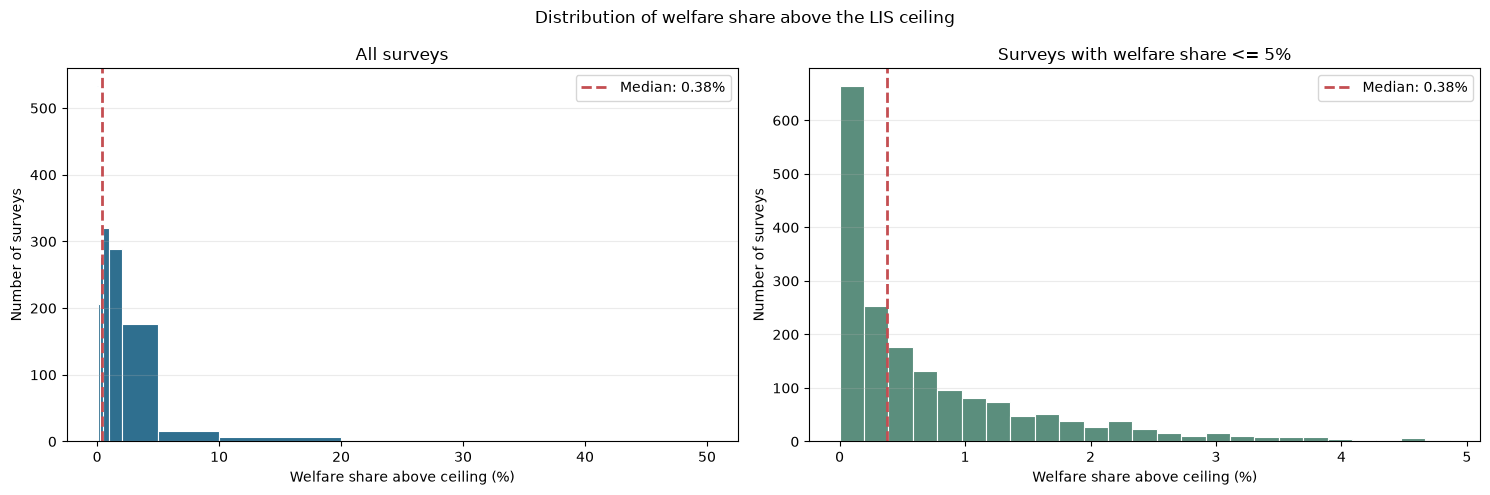

Surveys included: 1,825
Surveys with welfare share <= 5%: 1,801
Minimum: 0.0000%
Median: 0.3811%
Maximum: 41.5964%


In [ ]:
import matplotlib.pyplot as plt

welfare_share = pd.to_numeric(
    lis_screening_table['Welfare share above ceiling'],
    errors='coerce',
 ).dropna()

median_share = welfare_share.median()
bins = [0, 0.1, 0.25, 0.5, 1, 2, 5, 10, 20, 50]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].hist(
    welfare_share,
    bins=bins,
    color='#2f6f8f',
    edgecolor='white',
    linewidth=0.8,
 )
axes[0].axvline(
    median_share,
    color='#c44e52',
    linestyle='--',
    linewidth=2,
    label=f'Median: {median_share:.2f}%',
 )
axes[0].set_title('All surveys')
axes[0].set_xlabel('Welfare share above ceiling (%)')
axes[0].set_ylabel('Number of surveys')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)

zoomed_share = welfare_share[welfare_share <= 5]
axes[1].hist(
    zoomed_share,
    bins=25,
    color='#5b8e7d',
    edgecolor='white',
    linewidth=0.8,
 )
axes[1].axvline(
    median_share,
    color='#c44e52',
    linestyle='--',
    linewidth=2,
    label=f'Median: {median_share:.2f}%',
 )
axes[1].set_title('Surveys with welfare share <= 5%')
axes[1].set_xlabel('Welfare share above ceiling (%)')
axes[1].set_ylabel('Number of surveys')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)

tail_share = welfare_share[welfare_share >= 5]
axes[2].hist(
    tail_share,
    bins=15,
    color='#d08c60',
    edgecolor='white',
    linewidth=0.8,
 )
axes[2].set_title('Surveys with welfare share >= 5%')
axes[2].set_xlabel('Welfare share above ceiling (%)')
axes[2].set_ylabel('Number of surveys')
axes[2].grid(axis='y', alpha=0.25)

fig.suptitle('Distribution of welfare share above the LIS ceiling')
plt.tight_layout()
plt.show()

print(f'Surveys included: {len(welfare_share):,}')
print(f'Surveys with welfare share <= 5%: {len(zoomed_share):,}')
print(f'Surveys with welfare share >= 5%: {len(tail_share):,}')
print(f'Minimum: {welfare_share.min():.4f}%')
print(f'Median: {median_share:.4f}%')
print(f'Maximum: {welfare_share.max():.4f}%')